<a href="https://colab.research.google.com/github/ShajithSiva/Models/blob/Shajith/Expense_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

dataset = pd.read_csv("expense_prediction_dataset (1).csv")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                35000 non-null  object 
 1   Year                  35000 non-null  int64  
 2   Month                 35000 non-null  object 
 3   Age                   35000 non-null  int64  
 4   Occupation            35000 non-null  object 
 5   FamilySize            35000 non-null  int64  
 6   CityType              35000 non-null  object 
 7   MonthlyIncome         35000 non-null  float64
 8   Rent                  35000 non-null  float64
 9   Groceries             35000 non-null  float64
 10  Transportation        35000 non-null  float64
 11  Utilities             35000 non-null  float64
 12  Healthcare            35000 non-null  float64
 13  Education             35000 non-null  float64
 14  Entertainment         35000 non-null  float64
 15  Shopping           

In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

dataset["Month"] = encoder.fit_transform(dataset["Month"])
dataset["Occupation"] = encoder.fit_transform(dataset["Occupation"])
dataset["CityType"] = encoder.fit_transform(dataset["CityType"])

In [ ]:
X = dataset.drop(columns=[
    "UserID",
    "NextMonthExpense"
])

y = dataset["NextMonthExpense"]

print(X.shape)
print(y.shape)

(35000, 23)
(35000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(28000, 23)
(7000, 23)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Training Completed!")

Training Completed!


In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 21254.5
RMSE: 28657.17
R² : 0.9178


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)


,Feature,Importance
20,PreviousMonthExpense,0.528633
22,TotalExpense,0.216589
6,MonthlyIncome,0.150514
18,Investment,0.026480
4,FamilySize,0.009378
8,Groceries,0.008992
10,Utilities,0.006019
17,EMI_Loan,0.005689
11,Healthcare,0.005205
19,Savings,0.004947


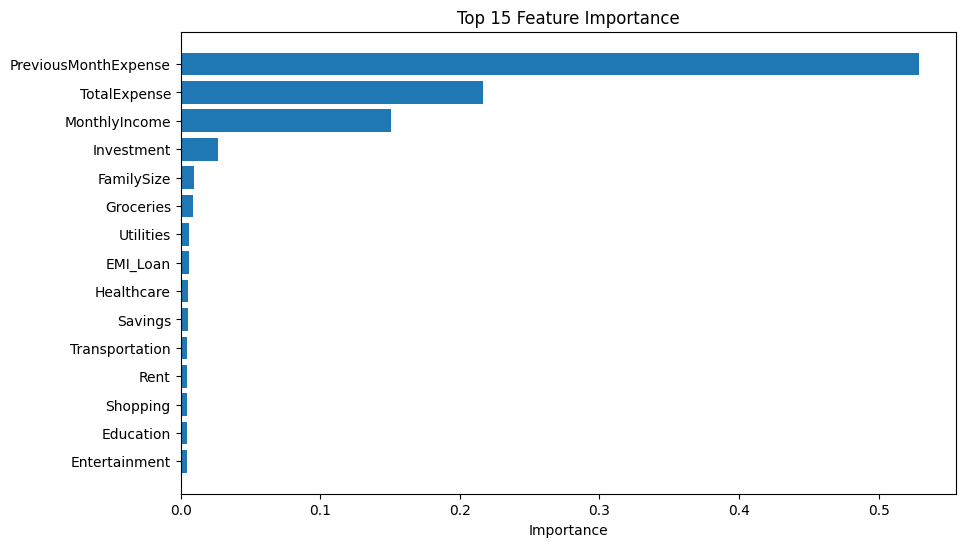

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance")

plt.show()


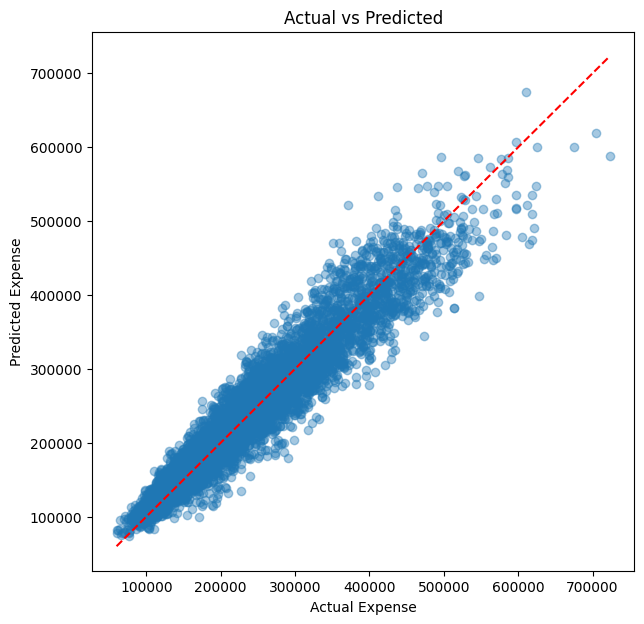

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Expense")
plt.ylabel("Predicted Expense")
plt.title("Actual vs Predicted")

plt.show()


In [ ]:
import joblib

joblib.dump(model, "expense_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [ ]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

results

,Metric,Value
0,MAE,21254.499895
1,RMSE,28657.173949
2,R²,0.917791


In [ ]:
results.to_csv("model_results.csv", index=False)

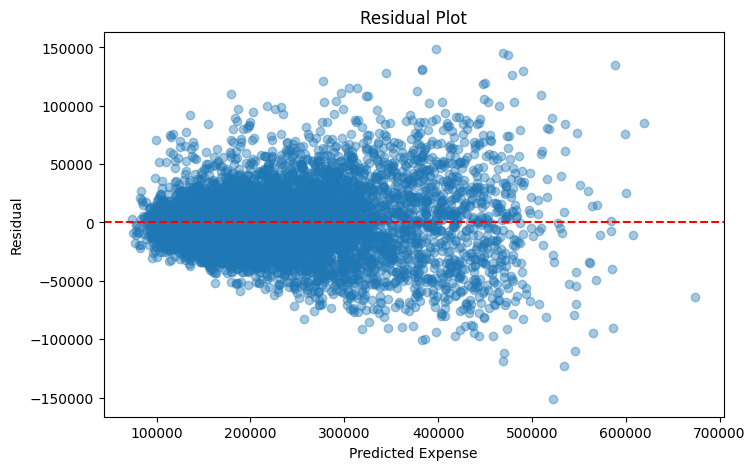

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - predictions

plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals, alpha=0.4)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Expense")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [ ]:
from google.colab import files

files.download("expense_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir("/content")

['.config',
 'city_encoder.pkl',
 '500_expense_tables.xlsx',
 'expense_prediction_dataset.csv',
 'expense_prediction_model.pkl',
 'expense_prediction_dataset (1).csv',
 'model_results.csv',
 '500_expense_tables (1).xlsx',
 'feature_names.pkl',
 'drive',
 'occupation_encoder.pkl',
 'month_encoder.pkl',
 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/expense_prediction_model.pkl"
)

print("Model saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive!
